In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os

# Add the modules/ folder to the Python path
module_path = os.path.abspath(os.path.join('..', 'modules'))
if module_path not in sys.path:
    sys.path.append(module_path)

from imports import *


2025-06-03 15:19:59,523 - INFO - Common imports loading...


Executing common imports from imports.py...


In [3]:
cosmotable = np.loadtxt('lhs_cosmo_samples_halofit.dat')
cosmotable_om = cosmotable[:,0]
cosmotable_h = cosmotable[:,1]
cosmotable_w0 = cosmotable[:,2]
cosmotable_sig8 =  cosmotable[:,3]
# cosmotable_oc = cosmotable[:,5]

# Define parameter bounds based on min and max values
param_bounds = np.array([
    [np.min(cosmotable_om), cosmotable_om.max()],
    [cosmotable_h.min(), cosmotable_h.max()],
    [cosmotable_w0.min(), cosmotable_w0.max()],
    [cosmotable_sig8.min(), cosmotable_sig8.max()],
    # [cosmotable_oc.min(), cosmotable_oc.max()]
])

print(param_bounds)
# Number of samples (adjust as needed)
num_samples = 100

# Generate Latin Hypercube Samples
sampler = qmc.LatinHypercube(d=param_bounds.shape[0])
lh_samples = sampler.random(n=num_samples)

# Scale samples to the parameter bounds
lh_scaled = qmc.scale(lh_samples, param_bounds[:, 0], param_bounds[:, 1])

# Convert to a structured array or DataFrame if needed

lh_df = pd.DataFrame(cosmotable[:,:], columns=["Om", "h", "w0", "sig8"])

# Display or save results
# print(lh_df)  # Print first few samples

cosmotable
lh_df

[[ 0.207638  0.392847]
 [ 0.601937  0.798149]
 [-1.390785 -0.616471]
 [ 0.608328  0.8927  ]]


,Om,h,w0,sig8
0,0.350144,0.707418,-1.216086,0.892700
1,0.387051,0.787803,-1.096119,0.824871
2,0.327102,0.781053,-0.836081,0.673094
3,0.339554,0.736514,-1.302878,0.849208
4,0.293866,0.620079,-0.616471,0.752039
5,0.229786,0.718291,-0.769299,0.814115
6,0.274505,0.609077,-1.011120,0.793373
7,0.309787,0.774507,-1.182791,0.764144
8,0.265733,0.735885,-1.137573,0.656508
9,0.371088,0.664167,-0.656677,0.623814


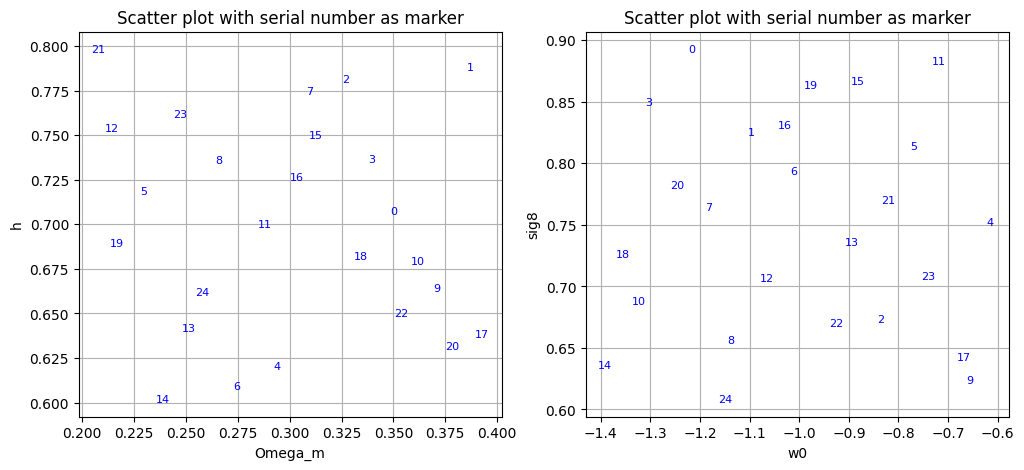

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
# Plot empty or invisible scatter just to define the plot area
plt.scatter(lh_df["Om"], lh_df["h"], color='white')  # optional background points

# Annotate with serial numbers as "markers"
for i, row in lh_df.iterrows():
    # if i==9 or i==14 or i==18:
    #     color='red'
    # else:
    color='blue'
    plt.text(row["Om"], row["h"], str(i), fontsize=8, color=color, ha='center', va='center')

plt.xlabel("Omega_m")
plt.ylabel("h")
plt.title("Scatter plot with serial number as marker")
plt.grid(True)

plt.subplot(1,2,2)
# Plot empty or invisible scatter just to define the plot area
plt.scatter(lh_df["w0"], lh_df["sig8"], color='white')  # optional background points

# Annotate with serial numbers as "markers"
for i, row in lh_df.iterrows():
    # if i==9 or i==14 or i==18:
    #     color='red'
    # else:
    color='blue'
    plt.text(row["w0"], row["sig8"], str(i), fontsize=8, color=color, ha='center', va='center')

plt.xlabel("w0")
plt.ylabel("sig8")
plt.title("Scatter plot with serial number as marker")
plt.grid(True)
plt.show()

Filter radius in pixels: 30
--- Running for Cosmology Index: 11 ---
Cosmological Parameters:
  h=0.6998, Om=0.2879, Oc=0.2406, Ob=0.0473, sigma8=0.8826, w0=-0.7188, wa=0.0000
Initializing Cosmology...for iteration  0
the min and max values of k are:  0.0001 1.5848931924611136 and length is:  200
Calculating lensing geometry...
  Source Redshift: 1.852, Comoving Distance: 3275.27 Mpc/h
  Number of lensing planes: 7
Initializing Variance and P(k)...
Variance module initialized.e final z: 0.19
Initializing VariablesGenerator...
Calculating sigmasq_map...
the shapes are:  (7,) (7,)
VariablesGenerator Initialized:
  Source Redshift (zs): 1.852
  Angular Scale (theta1): 15.0 arcmin
  Number of Planes: 7
  Using n(z) file: True
  Calculated Map Variance (sigmasq_map): 2.7027125601806496e-05
Theoretical Map Variance (sigmasq_map): 2.703e-05
Recalibration Value Set To: 1.0
Finding critical points...
Setting ngrid = 120. Increase this for more accuracy, but note that computation becomes slower!


/feynman/work/dap/lcs/vt272285/final_codes/LDT_2cell_l1_norm/modules/ratefunction_module.py:5: RuntimeWarning: invalid value encountered in power
  return nu * (1. - rho**(-1./nu))
/feynman/work/dap/lcs/vt272285/final_codes/LDT_2cell_l1_norm/modules/ratefunction_module.py:14: RuntimeWarning: invalid value encountered in sqrt
  sig2lr12 = variance.nonlinear_sigma2(redshift=z, R1=chi*((1+delta1[:,newaxis])**0.5)* theta1,
/feynman/work/dap/lcs/vt272285/final_codes/LDT_2cell_l1_norm/modules/ratefunction_module.py:15: RuntimeWarning: invalid value encountered in sqrt
  R2=chi*((1+delta2[:,newaxis])**0.5)*theta2)
/feynman/work/dap/lcs/vt272285/final_codes/LDT_2cell_l1_norm/modules/ratefunction_module.py:17: RuntimeWarning: invalid value encountered in sqrt
  sig2lr11 = variance.nonlinear_sigma2(redshift=z, R1=chi*((1+delta1[:,newaxis])**0.5)*theta1,
/feynman/work/dap/lcs/vt272285/final_codes/LDT_2cell_l1_norm/modules/ratefunction_module.py:18: RuntimeWarning: invalid value encountered in sqr

the coeffs are [-0.0003167   0.00147366 -0.00061329 -0.00503147  0.00455146  0.00527032
 -0.00197782 -0.003493  ]
3.911776122635673e-06
Calculating predicted L1 norm...
Prediction PDF Moments: Mean=-0.003502, Variance=3.628e-06, Skewness=7183, Kurtosis=259.5

--- Comparison ---
     Metric Prediction PDF
0      Mean      -0.003502
1  Variance      3.628e-06
2  Skewness           7183
3  Kurtosis          259.5
4      Norm              1
-----------------

--- Running for Cosmology Index: 23 ---
Cosmological Parameters:
  h=0.7619, Om=0.2474, Oc=0.2001, Ob=0.0473, sigma8=0.7085, w0=-0.7408, wa=0.0000
Initializing Cosmology...for iteration  0
the min and max values of k are:  0.0001 1.5848931924611136 and length is:  200
Calculating lensing geometry...
  Source Redshift: 1.852, Comoving Distance: 3388.36 Mpc/h
  Number of lensing planes: 7
Initializing Variance and P(k)...
Variance module initialized.e final z: 0.19
Initializing VariablesGenerator...
Calculating sigmasq_map...
the shapes

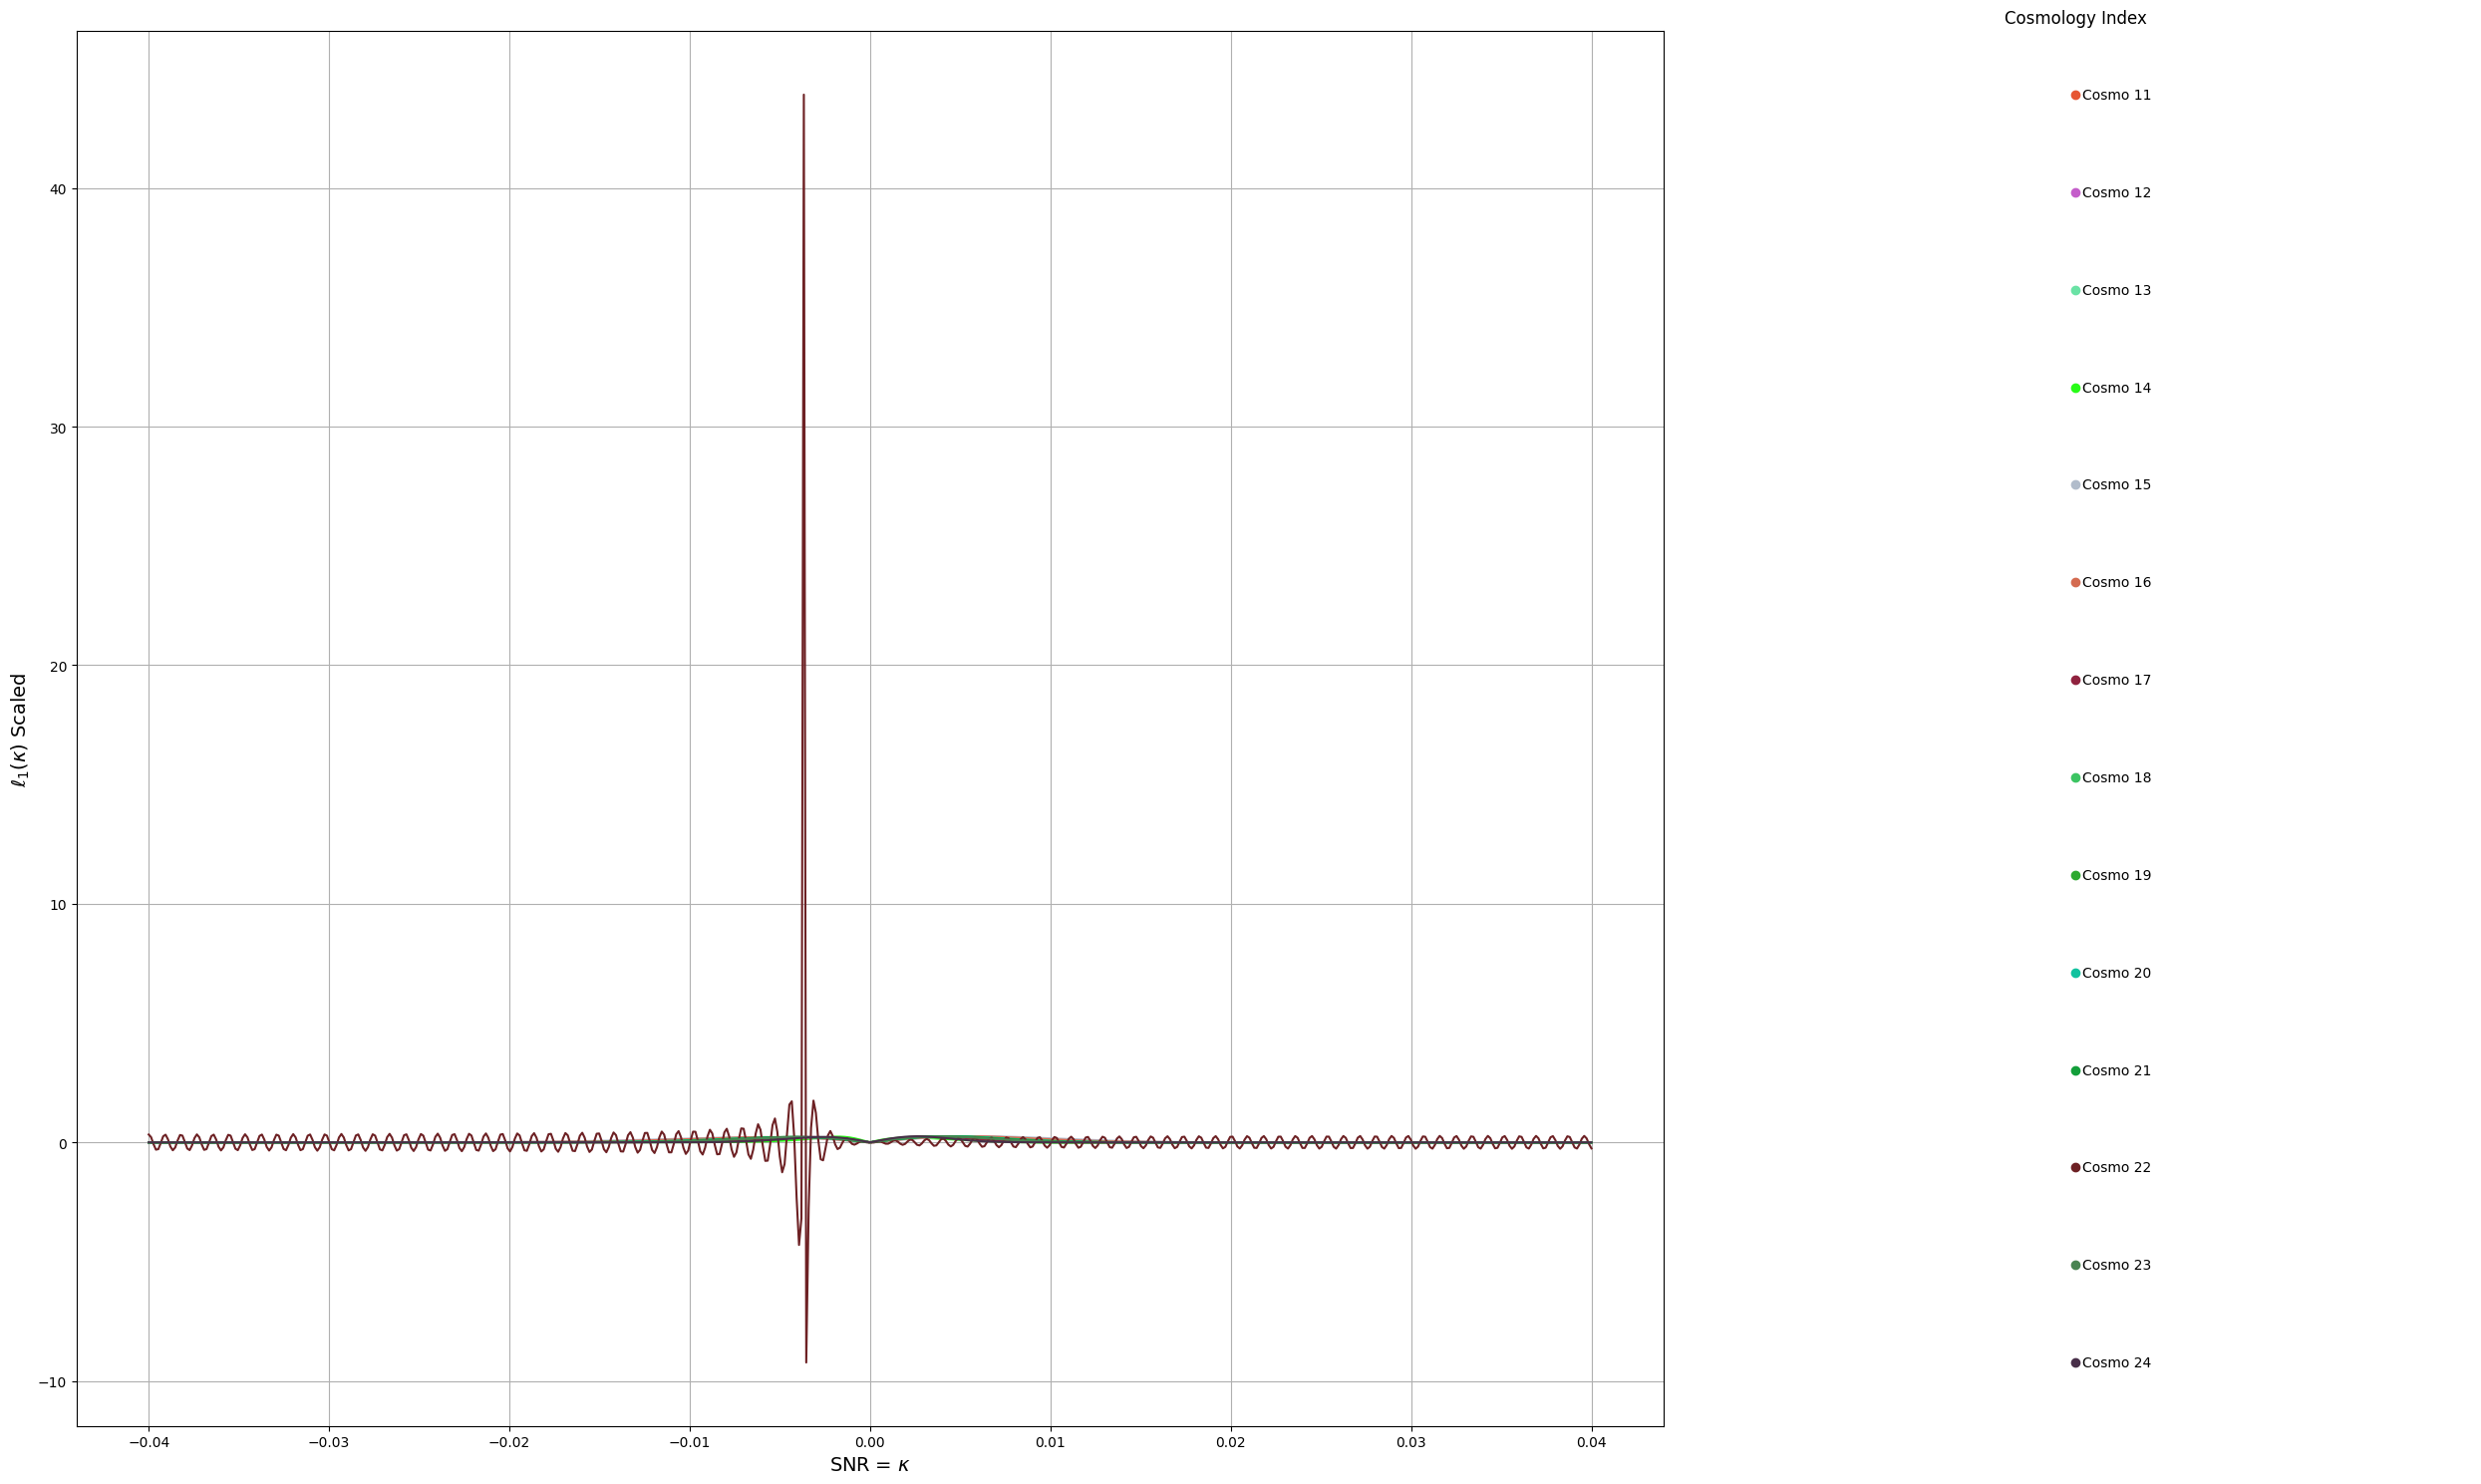

In [36]:
theta1_arcmin = 15.0  # Use a descriptive name
R_pixels = int(theta1_arcmin / 0.5) #0.5 arcmin/pixel resolution
print(f"Filter radius in pixels: {R_pixels}")

edges = np.linspace(-0.06, 0.06, 201)
centers = (edges[1:] + edges[:-1]) / 2
snr = np.linspace(-10, 10, 500) # Define SNR range for output interpolation

# Source redshift - can be single value or list depending on analysis needs
zs_source = 1.852 #1.134 # For this specific loop structure

# Path to n(z) file for the relevant bin
nz_file = "/feynman/work/dap/lcs/vt272285/LDT_2cell_l1_norm_recheck/nz_arrays_bin5.npy" 

# Parameters for calculations
kmin_pk = -4 # kmin for power spectrum calculation
kmax_pk = 0.2  # kmax for power spectrum calculation 
n_lensing_planes = 7 # Number of lensing planes

# --- Simulation Volume (Optional) ---
# Set to a float value in (Mpc/h)^3 if cosmic variance noise is desired in P(k)
simulation_volume = 1e7
variability = False

# --- Data Storage ---
l1_prediction_list = []
sigmasq_prediction_list = []
l1_simulation_list = []
l1_simulation_errorbars_list = []
simulation_pdf_list = []

# --- Plotting Setup ---
fig, axs = plt.subplots(1, 2, figsize=(25, 15), dpi=100, gridspec_kw={'width_ratios': [2, 1]})
# 
# --- Main Loop ---
# Loop directly over the desired cosmology index (or indices)

filter_type = 'tophat'
variances = []
l1_prediction_list = []

for cosmo_index_to_run in range(11,25):
    print(f"--- Running for Cosmology Index: {cosmo_index_to_run} ---")

    # --- Theoretical Prediction ---
    # 1. Get Cosmology Parameters from lh_df
    h = lh_df['h'][cosmo_index_to_run]
    Om = lh_df['Om'][cosmo_index_to_run]
    Ob = 0.0473
    sig8 = lh_df['sig8'][cosmo_index_to_run]
    w0 = lh_df['w0'][cosmo_index_to_run]
    wa = 0. # Assuming wa=0 based on original code
    Oc = Om - Ob # Calculate Ob consistently
    # Other fixed parameters from original code
    H0 = 100.0 * h # H0 in km/s/Mpc
    ns = 0.963
    mnu = 0.0

    print("Cosmological Parameters:")
    print(f"  h={h:.4f}, Om={Om:.4f}, Oc={Oc:.4f}, Ob={Ob:.4f}, sigma8={sig8:.4f}, w0={w0:.4f}, wa={wa:.4f}")

    for times in range(1):
        # 2. Initialize Cosmology
        print("Initializing Cosmology...for iteration ", times)
        cosmo = Cosmology_function(
            h=h, H0=H0, Ob=Ob, Oc=Oc, mnu=mnu, ns=ns, zs=zs_source, 
            w=w0, wa=wa, kmin=kmin_pk, kmax=kmax_pk, nz_file=nz_file, sigma8=sig8 
        )

        # 3. Calculate Geometric Quantities (Plane distances, weights)
        print("Calculating lensing geometry...")
        chi_source = cosmo.get_chi(zs_source)
        chis = np.linspace(0.3, chi_source - 5, n_lensing_planes) # Setup lensing planes
        dchis = np.ones(len(chis)) * (chis[1] - chis[0]) / 2 # Differential comoving distances
        dchis[1:-1] *= 2.

        if nz_file is not None:
            z_array, lensing_weight = cosmo.get_lensing_weight_array_nz(chis)
        else:
            # Need chi_source if using single source plane
            z_array, lensing_weight = cosmo.get_lensing_weight_array(chis, chi_source) 

        print(f"  Source Redshift: {zs_source}, Comoving Distance: {chi_source:.2f} Mpc/h")
        print(f"  Number of lensing planes: {n_lensing_planes}")

        # Determine appropriate redshift range based on z_array or zs_source
        max_crit_z = min(zs_source * 0.6, np.max(z_array)) if len(z_array)>0 else zs_source*0.95 # Avoid edge
        crit_point_z = np.linspace(0.001, zs_source * 0.1, 5) 

        # 4. Initialize Variance (this will compute P(k) internally)
        print("Initializing Variance and P(k)...")
        variance = Variance(
            cosmo=cosmo, 
            z_values=z_array,
            z_values_critical = crit_point_z,
            filter_type = filter_type,
            variability=variability, 
            delta_A0=.7 
        )

        # 5. Initialize VariablesGenerator (this calculates sigmasq_map)
        print("Initializing VariablesGenerator...")
        variables = VariablesGenerator(
            cosmo=cosmo, 
            variance=variance, 
            zs=zs_source, 
            theta1=theta1_arcmin, 
            nz_file=nz_file, 
            nplanes=n_lensing_planes,
            chis=chis, 
            dchis=dchis, 
            z_array=z_array, 
            lensing_weight=lensing_weight
        )

        variables.recal_value = 1.0 
        # If recalibration based on simulation variance is desired:
        print(f"Theoretical Map Variance (sigmasq_map): {variables.sigmasq_map:.4g}")
        print(f"Recalibration Value Set To: {variables.recal_value}") 
        variances.append(variables.sigmasq_map)
        
        # 6. Find Critical Points
        print("Finding critical points...")
        criticalpoints = CriticalPointsFinder(variables, ngrid=120, plot=False) 
        critical_values_list = []
        print(f"  Redshift range for critical points: {crit_point_z}")
        for z_crit in crit_point_z:
            crit_vals = criticalpoints.get_critical_points(z_crit)
            # crit_vals = criticalpoints.find_critical_points_grid_scipy(z_crit, deld=1e-4, initial_guesses=[(-0.5, -0.5), (.5, .5)])
            print(f"  Critical points for z={z_crit:.7f}: {crit_vals}")
            if crit_vals is not None and len(crit_vals) >= 2:
                critical_values_list.append(crit_vals[:2])
            if crit_vals is not None and len(crit_vals) == 1:
                critical_values_list.append([np.nan,crit_vals[0]]) 
        if not critical_values_list:
            print("  Warning: No critical points found in the specified redshift range.")
            smallest_pair_info = None
        else:
            critical_values_array = np.array(critical_values_list)
            flat_values = []
            for item in critical_values_list:
                if isinstance(item, (np.ndarray, list)):
                    flat_values.extend(np.ravel(item))
                else:
                    flat_values.append(item)

            flat_values = np.array(flat_values)

            # Remove NaNs if any
            flat_values = flat_values[~np.isnan(flat_values)]

            # Smallest positive value
            positive_values = flat_values[flat_values > 0]
            smallest_positive = np.min(positive_values) if positive_values.size > 0 else None

            # Largest negative value
            negative_values = flat_values[flat_values < 0]
            largest_negative = np.max(negative_values) if negative_values.size > 0 else None

            print("Smallest positive value:", smallest_positive)
            print("Largest negative value:", largest_negative)
            print("Smallest distance pair of critical points:", smallest_positive, largest_negative)

        # 7. Compute PDF
        print("Computing PDF...")
        # Set lambda range based on critical points if found
        if smallest_positive and largest_negative is not None:
            # Add buffer around the critical lambda values
            lambda_min = largest_negative + 0 # Adjust buffer as needed
            lambda_max = smallest_positive - 0 # Adjust buffer as needed
            variables.lambdas = np.linspace(lambda_min, lambda_max, 20) # Use dynamic range
            print(f"  Using lambda range: [{lambda_min:.2f}, {lambda_max:.2f}]")
        else:
            # Fallback lambda range if critical points not found or invalid
            variables.lambdas = np.linspace(-80, 200, 100) 
            print("  Warning: Using fallback lambda range.")
        
        
        # if 0 < cosmo_index_to_run < 5:
        #     variables.lambdas = np.linspace(-70, 350, 20) 
        # elif cosmo_index_to_run == 0:
        #     variables.lambdas = np.linspace(-100, 450, 20) 
        # elif 5 <= cosmo_index_to_run < 9:
        #     variables.lambdas = np.linspace(-70, 310, 20) 
        # elif cosmo_index_to_run == 9:
        #     variables.lambdas = np.linspace(-800, 1450, 20)
        # elif 10<= cosmo_index_to_run < 15 and cosmo_index_to_run != 12:
        #     variables.lambdas = np.linspace(-110, 500, 20) #12
        # elif cosmo_index_to_run == 12:
        #     variables.lambdas = np.linspace(-700, 1600, 20)
        # elif cosmo_index_to_run == 15:
        #     variables.lambdas = np.linspace(-250, 670, 20)
        # elif 15 < cosmo_index_to_run < 20:
        #     variables.lambdas = np.linspace(-100, 350, 20) #15
        # elif 20 <= cosmo_index_to_run < 25:
        #     variables.lambdas = np.linspace(-110, 500, 20)
        
        computed_PDF = computePDF(variables, plot_scgf=False) # Pass the updated variables object
        pdf_values, kappa_values = computed_PDF.pdf_values, computed_PDF.kappa_values

        # 8. Calculate Predicted L1 norm
        print("Calculating predicted L1 norm...")
        # pdf_spline = CubicSpline(kappa_values, pdf_values) 
        l1_pred_values = get_l1_from_pdf(pdf_values, kappa_values)

        # Store predictions
        sigmasq_prediction_list.append(variables.sigmasq_map)
        l1_prediction_list.append(l1_pred_values)
        
        # Plotting L1 comparison
        # fig, axs = plt.subplots(1, 2, figsize=(25, 15), dpi=100, gridspec_kw={'width_ratios': [2, 1]})
        colour = list(np.random.choice(range(256), size=3) / 255) # Random color for this run
        plot_scale_factor = 1.0 # 
        axs[0].plot(kappa_values, l1_pred_values * plot_scale_factor, alpha=1., c=colour) 
        # axs[0].plot(kappa_values, pdf_values , alpha=1., c=colour, lw=4) 
        
        # Calculate moments from predicted PDF
        pred_stats = get_moments(kappa_values, pdf_values)
        pred_mean, pred_var, pred_skew, pred_kurt, pred_norm = pred_stats
        print(f"Prediction PDF Moments: Mean={pred_mean:.4g}, Variance={pred_var:.4g}, Skewness={pred_skew:.4g}, Kurtosis={pred_kurt:.4g}")

        # --- Comparison and Plotting ---
        print("\n--- Comparison ---")
        comparison_data = {
            "Metric": ["Mean", "Variance", "Skewness", "Kurtosis", "Norm"],
            "Prediction PDF": [f"{v:.4g}" for v in pred_stats],
            # "Simulation Avg PDF": [f"{v:.4g}" for v in sim_stats],
        }
        df_comp = pd.DataFrame(comparison_data)
        print(df_comp)
        print("-----------------\n")
    
        axs[1].scatter(1, 25 - cosmo_index_to_run, color=colour) # Adjust y-positioning as needed
        axs[1].annotate(f"Cosmo {cosmo_index_to_run}", (1, 25 - cosmo_index_to_run), xytext=(5, 0), textcoords='offset points', va='center')

# --- Final Plot Formatting ---
# axs[0].hlines(0, np.min(x_axis_vals), np.max(x_axis_vals), color='gray', ls='--')
# axs[0].axhspan(-0.05 * plot_scale_factor, 0.05 * plot_scale_factor, color='gray', alpha=0.2) # Adjust span based on plot scale
axs[0].set_xlabel(r'SNR = $\kappa$', size=14) 
axs[0].set_ylabel(r'$\ell_1(\kappa)$ Scaled', size=14) # Adjust label if scale factor changes
# Set xlim based on plotted range, e.g., +/- 3 sigma
# xlim_range = 5 * pred_stdev 
# axs[0].set_xlim(-5, 5) 



# ylim can be set dynamically or fixed
# axs[0].set_ylim(-0.1 * plot_scale_factor, np.nanmax(l1_pred_on_snr * plot_scale_factor) * 1.1) 
axs[0].grid(True, which='both', axis='both')
# axs[0].legend() # Add legend to the main plot

# Format the second axes panel (cosmology labels)
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_xticklabels([])
axs[1].set_yticklabels([])
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].spines['bottom'].set_visible(False)
axs[1].spines['left'].set_visible(False)
axs[1].set_title("Cosmology Index")

plt.tight_layout()
plt.show()

In [145]:
# l1_prediction_list = np.array(l1_prediction_list)
# sigmasq_prediction_list = np.array(sigmasq_prediction_list)
# data = {
#     'l1_prediction_list': l1_prediction_list,
#     'sigmasq_prediction_list': sigmasq_prediction_list,
#     'kaappa_values': kappa_values,
# }

# np.save("l1_prediction_data_new_cosmos.npy", data)